In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
geolocation = pd.read_csv("olist_geolocation_dataset.csv")
category_translation = pd.read_csv("product_category_name_translation.csv")

In [3]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Payments": payments,
    "Products": products,
    "Sellers": sellers,
    "Reviews": reviews
}
for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * 50)
    print("Shape:", df.shape)
    print(df.head())


Customers
--------------------------------------------------
Shape: (99441, 5)
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  

Orders
--------------------------------------------------
Shape: (99441,

In [4]:
for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * 50)
    print("Missing Values:")
    print(df.isnull().sum())
    print("\nDuplicate Rows:")
    print(df.duplicated().sum())
    print("\nData Types:")
    print(df.dtypes)


Customers
--------------------------------------------------
Missing Values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Duplicate Rows:
0

Data Types:
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

Orders
--------------------------------------------------
Missing Values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Duplicate Rows:
0

Data Types:
order_id                         object
customer_id                      object
order_status                     o

In [5]:
summary = pd.DataFrame({
    "Dataset": list(datasets.keys()),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

summary

,Dataset,Rows,Columns
0,Customers,99441,5
1,Orders,99441,8
2,Order Items,112650,7
3,Payments,103886,5
4,Products,32951,9
5,Sellers,3095,4
6,Reviews,99224,7


# Data Loading Summary

The Olist dataset consists of multiple related tables containing information about customers, orders, products, sellers, payments, and reviews.

Initial exploration was performed to understand:
- Dataset dimensions
- Data types
- Missing values
- Duplicate records

This step helps identify data quality issues before analysis begins.

In [6]:
for name, df in datasets.items():
    missing = (
        df.isnull()
        .sum()
        .sort_values(ascending=False)
    )
    missing_percent = (
        missing / len(df)
    ) * 100
    report = pd.DataFrame({
        "Missing Values": missing,
        "Percentage": missing_percent
    })
    print(f"\n{name}")
    print(report[report["Missing Values"] > 0])


Customers
Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []

Orders
                               Missing Values  Percentage
order_delivered_customer_date            2965    2.981668
order_delivered_carrier_date             1783    1.793023
order_approved_at                         160    0.160899

Order Items
Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []

Payments
Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []

Products
                            Missing Values  Percentage
product_category_name                  610    1.851234
product_description_lenght             610    1.851234
product_name_lenght                    610    1.851234
product_photos_qty                     610    1.851234
product_weight_g                         2    0.006070
product_height_cm                        2    0.006070
product_length_cm                        2    0.006070
product_width_cm                         2    0.006070

Sellers
Empty DataFrame
Colu

In [7]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)
orders["order_approved_at"] = pd.to_datetime(
    orders["order_approved_at"]
)
orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)
orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

In [8]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](4), object(4)
memory usage: 6.1+ MB


# Which product categories generate the highest revenue?

In [9]:
products = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [10]:
sales_data = order_items.merge(
    products,
    on="product_id",
    how="left"
)
sales_data.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


In [11]:
sales_data["revenue"] = (
    sales_data["price"] +
    sales_data["freight_value"]
)
sales_data[[
    "product_id",
    "price",
    "freight_value",
    "revenue"
]].head()

,product_id,price,freight_value,revenue
0,4244733e06e7ecb4970a6e2683c13e61,58.90,13.29,72.19
1,e5f2d52b802189ee658865ca93d83a8f,239.90,19.93,259.83
2,c777355d18b72b67abbeef9df44fd0fd,199.00,17.87,216.87
3,7634da152a4610f1595efa32f14722fc,12.99,12.79,25.78
4,ac6c3623068f30de03045865e4e10089,199.90,18.14,218.04


In [12]:
category_revenue = (
    sales_data.groupby(
        "product_category_name_english"
    )["revenue"]
    .sum()
    .sort_values(ascending=False)
)
category_revenue.head(10)

product_category_name_english
health_beauty            1441248.07
watches_gifts            1305541.61
bed_bath_table           1241681.72
sports_leisure           1156656.48
computers_accessories    1059272.40
furniture_decor           902511.79
housewares                778397.77
cool_stuff                719329.95
auto                      685384.32
garden_tools              584219.21
Name: revenue, dtype: float64

In [13]:
top_categories = (
    category_revenue
    .reset_index()
    .head(10)
)
top_categories

,product_category_name_english,revenue
0,health_beauty,1441248.07
1,watches_gifts,1305541.61
2,bed_bath_table,1241681.72
3,sports_leisure,1156656.48
4,computers_accessories,1059272.40
5,furniture_decor,902511.79
6,housewares,778397.77
7,cool_stuff,719329.95
8,auto,685384.32
9,garden_tools,584219.21


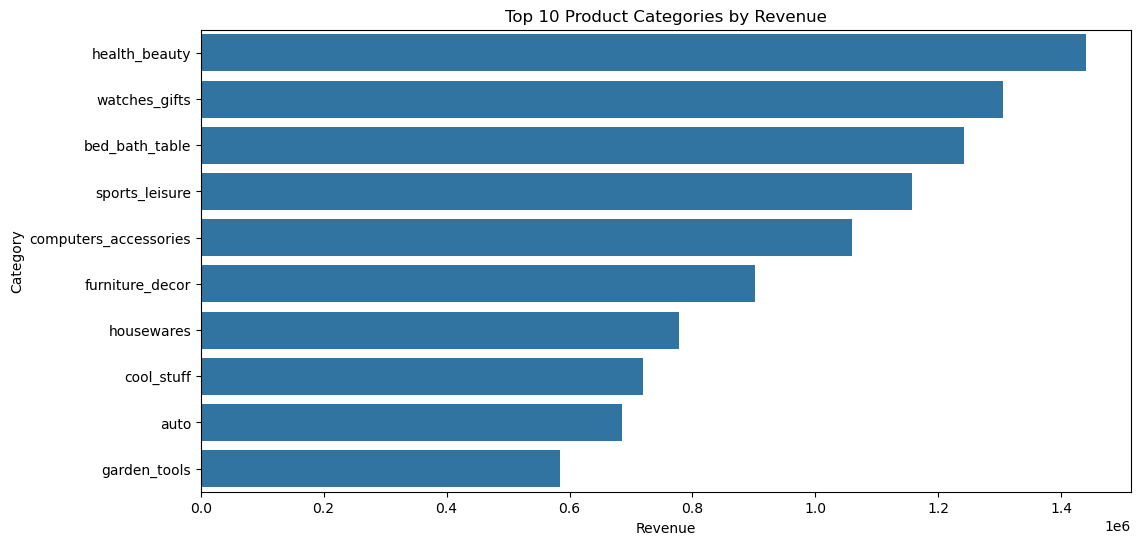

In [14]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_categories,
    x="revenue",
    y="product_category_name_english"
)
plt.title(
    "Top 10 Product Categories by Revenue"
)
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.show()

## Business Insight

The analysis shows that a small number of product categories contribute a significant portion of total revenue.

The top-performing categories should receive additional marketing investment and inventory support because they have the strongest impact on business performance.

Lower-performing categories may require promotional campaigns or product assortment review to improve sales contribution.

In [15]:
top_categories.to_csv(
    "top_category_revenue.csv",
    index=False
)

# Which cities or regions contribute the most sales?

In [16]:
customer_orders = orders.merge(
    customers,
    on="customer_id",
    how="left"
)
customer_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [17]:
region_sales = customer_orders.merge(
    order_items,
    on="order_id",
    how="left"
)
region_sales.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [18]:
region_sales["revenue"] = (
    region_sales["price"] +
    region_sales["freight_value"]
)

In [19]:
state_sales = (
    region_sales.groupby(
        "customer_state"
    )["revenue"]
    .sum()
    .sort_values(ascending=False)
)
state_sales.head(10)

customer_state
SP    5921678.12
RJ    2129681.98
MG    1856161.49
RS     885826.76
PR     800935.44
BA     611506.67
SC     610213.60
DF     353229.44
GO     347706.93
ES     324801.91
Name: revenue, dtype: float64

In [20]:
top_states = (
    state_sales
    .reset_index()
)
top_states.columns = [
    "State",
    "Revenue"
]
top_states.head(10)

,State,Revenue
0,SP,5921678.12
1,RJ,2129681.98
2,MG,1856161.49
3,RS,885826.76
4,PR,800935.44
5,BA,611506.67
6,SC,610213.60
7,DF,353229.44
8,GO,347706.93
9,ES,324801.91


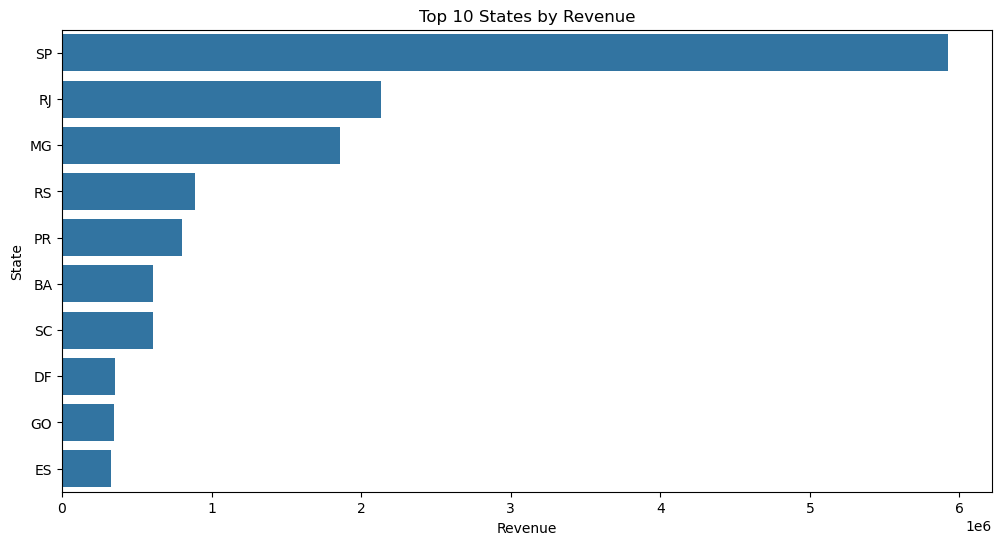

In [21]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_states.head(10),
    x="Revenue",
    y="State"
)
plt.title(
    "Top 10 States by Revenue"
)
plt.xlabel("Revenue")
plt.ylabel("State")
plt.show()

In [22]:
top_states["Revenue %"] = (
    top_states["Revenue"] /
    top_states["Revenue"].sum()
) * 100

top_states.head(10)

,State,Revenue,Revenue %
0,SP,5921678.12,37.375947
1,RJ,2129681.98,13.441947
2,MG,1856161.49,11.715563
3,RS,885826.76,5.591086
4,PR,800935.44,5.055277
5,BA,611506.67,3.859656
6,SC,610213.60,3.851495
7,DF,353229.44,2.229484
8,GO,347706.93,2.194627
9,ES,324801.91,2.050057


In [23]:
state_orders = (
    region_sales.groupby(
        "customer_state"
    )["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

state_orders.head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: order_id, dtype: int64

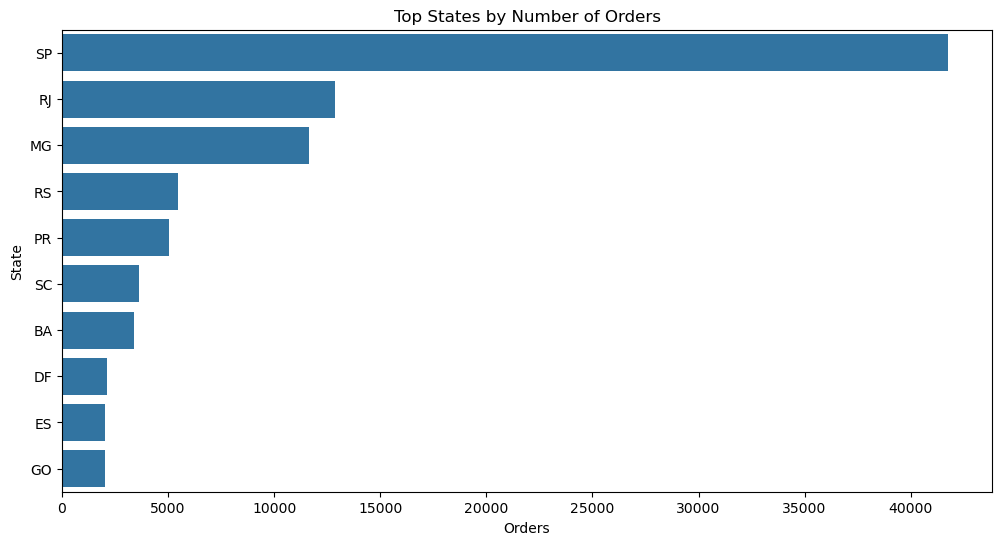

In [24]:
plt.figure(figsize=(12,6))
sns.barplot(
    x=state_orders.head(10).values,
    y=state_orders.head(10).index
)
plt.title(
    "Top States by Number of Orders"
)
plt.xlabel("Orders")
plt.ylabel("State")
plt.show()

## Business Insight

The analysis reveals that a small number of states generate a large share of total revenue and orders.

These high-performing regions represent the company's strongest markets and should be prioritized for marketing campaigns, inventory planning, and customer retention strategies.

States with lower revenue but reasonable order volume may present opportunities for future growth through targeted promotions and localized business strategies.

# Which customer segments provide the highest business value?

In [26]:
customer_value = region_sales.groupby(
    "customer_unique_id"
)["revenue"].sum().reset_index()

customer_value.columns = [
    "customer_unique_id",
    "total_spent"
]
customer_value.head()

,customer_unique_id,total_spent
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19
2,0000f46a3911fa3c0805444483337064,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89


In [27]:
customer_value["segment"] = pd.qcut(
    customer_value["total_spent"],
    q=3,
    labels=["Low Value", "Regular", "VIP"]
)
customer_value.head()

,customer_unique_id,total_spent,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,Regular
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,Low Value
2,0000f46a3911fa3c0805444483337064,86.22,Regular
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,Low Value
4,0004aac84e0df4da2b147fca70cf8255,196.89,VIP


In [28]:
segment_count = customer_value.groupby(
    "segment"
).size().reset_index(name="customers")

segment_count

C:\Users\ACER\AppData\Local\Temp\ipykernel_8380\3738862447.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_count = customer_value.groupby(


,segment,customers
0,Low Value,32042
1,Regular,32023
2,VIP,32031


In [29]:
segment_revenue = customer_value.groupby(
    "segment"
)["total_spent"].sum().reset_index()
segment_revenue

C:\Users\ACER\AppData\Local\Temp\ipykernel_8380\1367062753.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_revenue = customer_value.groupby(


,segment,total_spent
0,Low Value,1555861.91
1,Regular,3494132.59
2,VIP,10793558.74


In [30]:
segment_avg = customer_value.groupby(
    "segment"
)["total_spent"].mean().reset_index()
segment_avg

C:\Users\ACER\AppData\Local\Temp\ipykernel_8380\4062328717.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_avg = customer_value.groupby(


,segment,total_spent
0,Low Value,48.556954
1,Regular,109.113218
2,VIP,336.972269


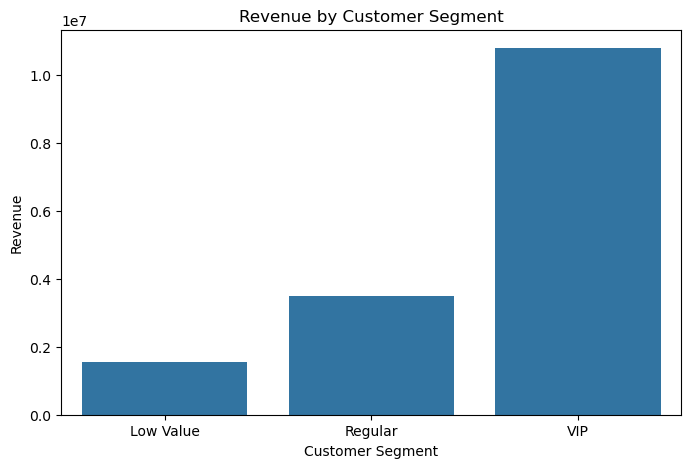

In [31]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=segment_revenue,
    x="segment",
    y="total_spent"
)
plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")
plt.show()

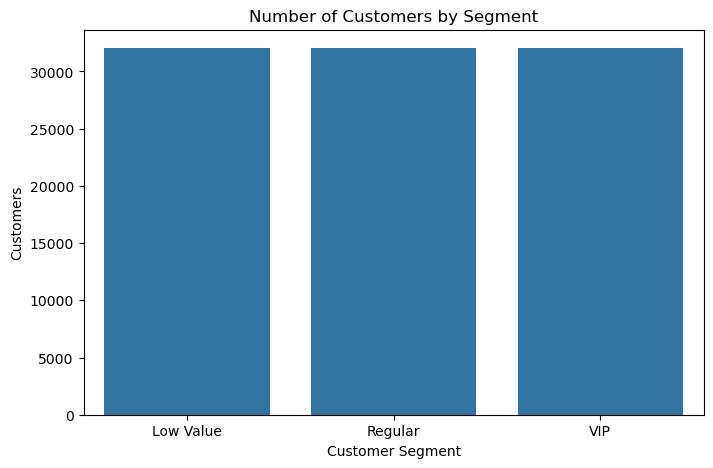

In [32]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=segment_count,
    x="segment",
    y="customers"
)
plt.title("Number of Customers by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Customers")
plt.show()

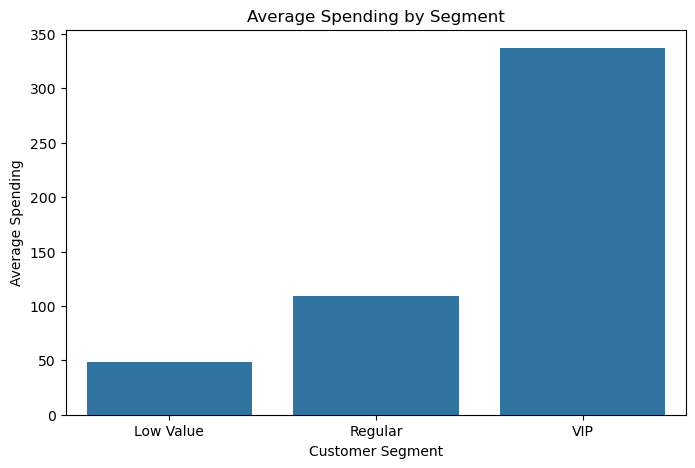

In [33]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=segment_avg,
    x="segment",
    y="total_spent"
)
plt.title("Average Spending by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Spending")
plt.show()

In [34]:
segment_revenue["revenue_percent"] = (
    segment_revenue["total_spent"] /
    segment_revenue["total_spent"].sum()
) * 100
segment_revenue

,segment,total_spent,revenue_percent
0,Low Value,1555861.91,9.820158
1,Regular,3494132.59,22.053971
2,VIP,10793558.74,68.125872


In [35]:
segment_revenue.to_csv(
    "customer_segment_analysis.csv",
    index=False
)

## Business Insight

Customer segmentation reveals that VIP customers contribute a disproportionately large share of total revenue compared to other customer groups.

Although VIP customers represent a smaller portion of the customer base, they generate the highest average spending and overall business value.

The company should focus on retention programs, personalized offers, and loyalty rewards for VIP customers while encouraging Regular customers to move into higher-value segments.

# What purchasing patterns can be observed in customer buying behavior?

In [36]:
customer_orders = orders.merge(
    customers,
    on="customer_id",
    how="left"
)
purchase_frequency = customer_orders.groupby(
    "customer_unique_id"
)["order_id"].count().reset_index()
purchase_frequency.columns = [
    "customer_unique_id",
    "total_orders"
]
purchase_frequency.head()

,customer_unique_id,total_orders
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [37]:
frequency_table = purchase_frequency[
    "total_orders"
].value_counts().sort_index()
print(frequency_table)

total_orders
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64


In [38]:
repeat_customers = (
    purchase_frequency["total_orders"] > 1
).sum()
one_time_customers = (
    purchase_frequency["total_orders"] == 1
).sum()
print("Repeat Customers:", repeat_customers)
print("One-Time Customers:", one_time_customers)

Repeat Customers: 2997
One-Time Customers: 93099


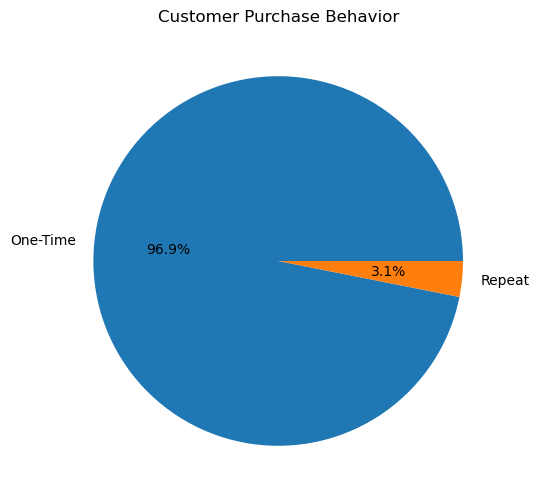

In [39]:
plt.figure(figsize=(6,6))
plt.pie(
    [one_time_customers, repeat_customers],
    labels=[
        "One-Time",
        "Repeat"
    ],
    autopct="%1.1f%%"
)
plt.title(
    "Customer Purchase Behavior"
)
plt.show()

In [40]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["purchase_month"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
)

monthly_orders = (
    orders.groupby("purchase_month")
    .size()
    .reset_index(name="orders")
)

monthly_orders.head()

,purchase_month,orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


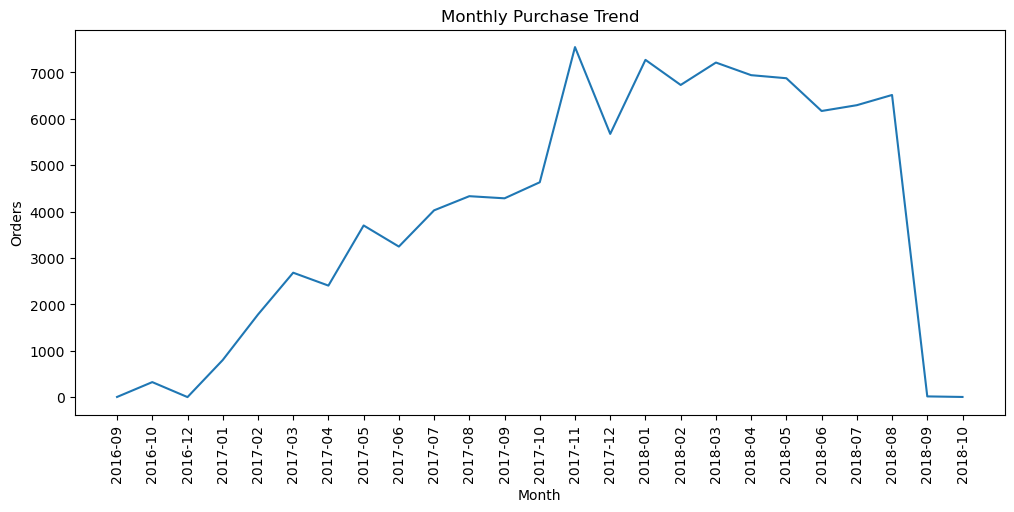

In [41]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_orders["purchase_month"]
    .astype(str),

    monthly_orders["orders"]
)
plt.title(
    "Monthly Purchase Trend"
)
plt.xlabel("Month")
plt.ylabel("Orders")
plt.xticks(rotation=90)
plt.show()

In [42]:
order_revenue = region_sales.groupby(
    "order_id"
)["revenue"].sum().reset_index()
average_order_value = (
    order_revenue["revenue"].mean()
)
print(
    "Average Order Value:",
    round(average_order_value, 2)
)

Average Order Value: 159.33


In [43]:
orders["day_name"] = (
    orders["order_purchase_timestamp"]
    .dt.day_name()
)

day_orders = (
    orders["day_name"]
    .value_counts()
)
print(day_orders)

day_name
Monday       16196
Tuesday      15963
Wednesday    15552
Thursday     14761
Friday       14122
Sunday       11960
Saturday     10887
Name: count, dtype: int64


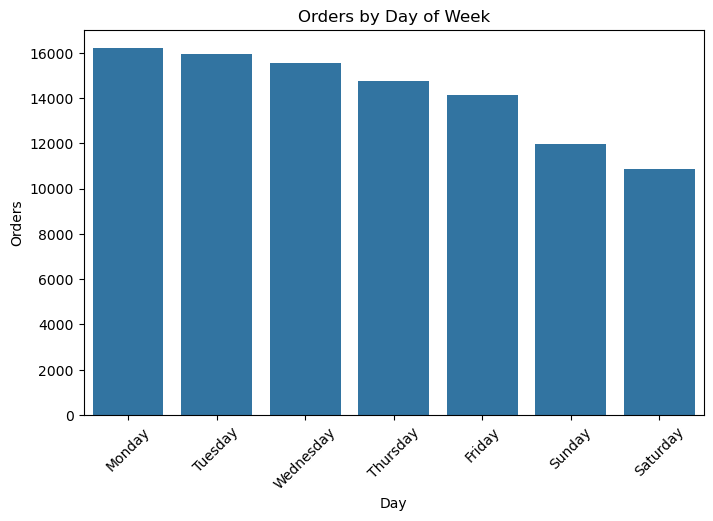

In [44]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=day_orders.index,
    y=day_orders.values
)
plt.title(
    "Orders by Day of Week"
)
plt.xlabel("Day")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.show()

In [45]:
purchase_frequency.to_csv(
    "customer_purchase_frequency.csv",
    index=False
)

## Business Insight

The majority of customers are one-time buyers, indicating that customer retention is a potential area for improvement.

Monthly purchase trends reveal periods of higher and lower demand, which can support inventory planning and marketing campaigns.

The average order value provides a useful benchmark for measuring customer spending behavior, while day-of-week analysis helps identify peak purchasing periods.

# Which products show the highest sales volume and revenue contribution?

In [46]:
product_sales = order_items.merge(
    products,
    on="product_id",
    how="left"
)
product_sales.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


In [47]:
product_sales["revenue"] = (
    product_sales["price"] +
    product_sales["freight_value"]
)

In [48]:
top_volume = (
    product_sales.groupby(
        "product_category_name_english"
)
    .size()
    .reset_index(name="units_sold")
    .sort_values(
        by="units_sold",
        ascending=False
    )
)
top_volume.head(10)

,product_category_name_english,units_sold
7,bed_bath_table,11115
43,health_beauty,9670
65,sports_leisure,8641
39,furniture_decor,8334
15,computers_accessories,7827
49,housewares,6964
70,watches_gifts,5991
68,telephony,4545
42,garden_tools,4347
5,auto,4235


In [49]:
top_revenue = (
    product_sales.groupby(
        "product_category_name_english"
    )["revenue"]
    .sum()
    .reset_index()
    .sort_values(
        by="revenue",
        ascending=False
    )
)
top_revenue.head(10)

,product_category_name_english,revenue
43,health_beauty,1441248.07
70,watches_gifts,1305541.61
7,bed_bath_table,1241681.72
65,sports_leisure,1156656.48
15,computers_accessories,1059272.40
39,furniture_decor,902511.79
49,housewares,778397.77
20,cool_stuff,719329.95
5,auto,685384.32
42,garden_tools,584219.21


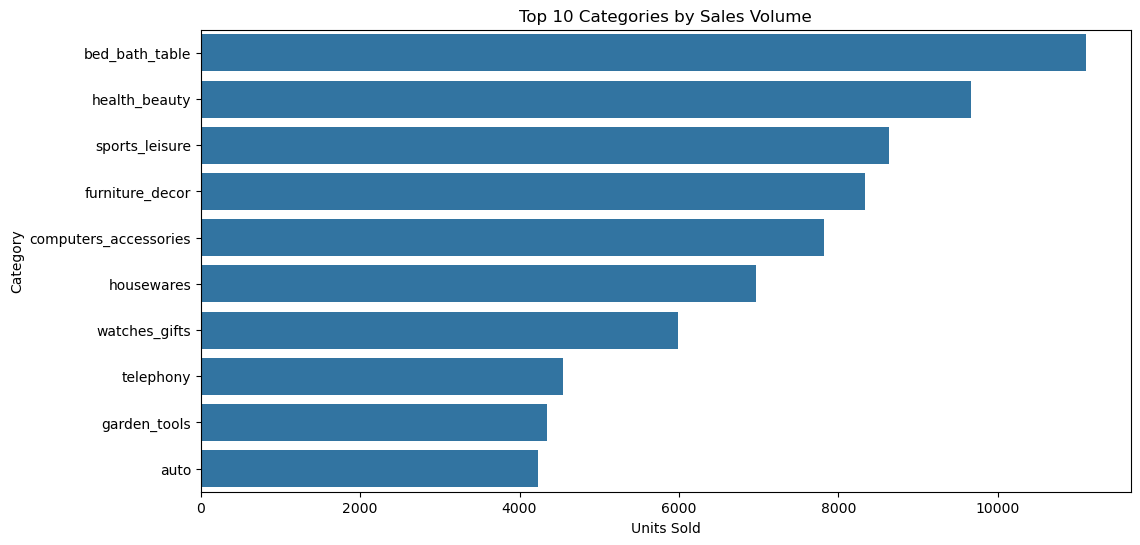

In [50]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_volume.head(10),
    x="units_sold",
    y="product_category_name_english"
)
plt.title(
    "Top 10 Categories by Sales Volume"
)
plt.xlabel("Units Sold")
plt.ylabel("Category")
plt.show()

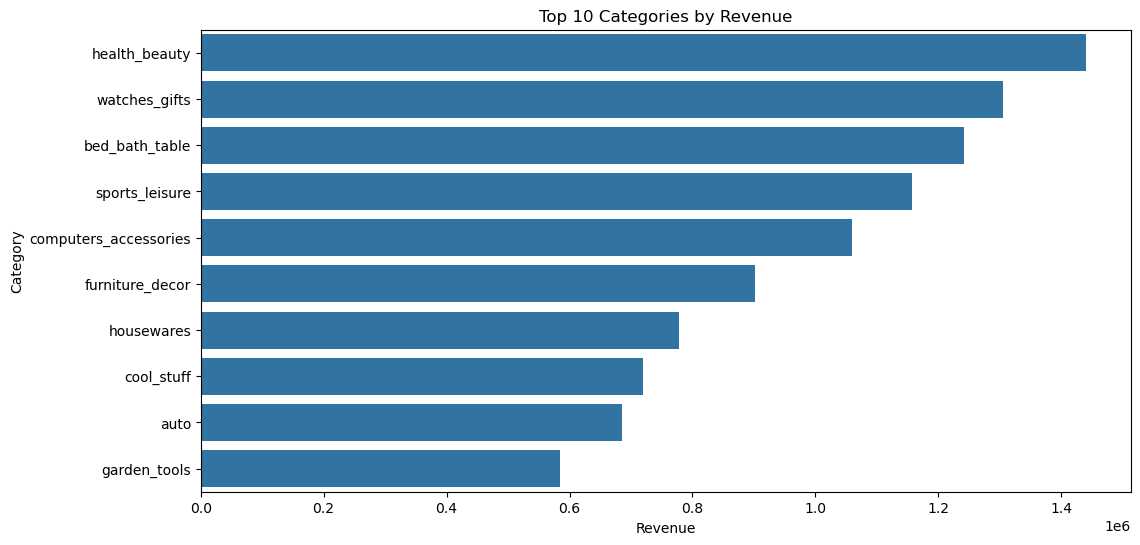

In [51]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_revenue.head(10),
    x="revenue",
    y="product_category_name_english"
)
plt.title(
    "Top 10 Categories by Revenue"
)
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.show()

In [52]:
top_revenue["revenue_percent"] = (
    top_revenue["revenue"] /
    top_revenue["revenue"].sum()
) * 100
top_revenue.head(10)

,product_category_name_english,revenue,revenue_percent
43,health_beauty,1441248.07,9.221102
70,watches_gifts,1305541.61,8.352852
7,bed_bath_table,1241681.72,7.944277
65,sports_leisure,1156656.48,7.400285
15,computers_accessories,1059272.40,6.777222
39,furniture_decor,902511.79,5.774268
49,housewares,778397.77,4.980187
20,cool_stuff,719329.95,4.602271
5,auto,685384.32,4.385087
42,garden_tools,584219.21,3.737833


In [53]:
product_ranking = (
    top_revenue.head(10)
)
product_ranking

,product_category_name_english,revenue,revenue_percent
43,health_beauty,1441248.07,9.221102
70,watches_gifts,1305541.61,8.352852
7,bed_bath_table,1241681.72,7.944277
65,sports_leisure,1156656.48,7.400285
15,computers_accessories,1059272.40,6.777222
39,furniture_decor,902511.79,5.774268
49,housewares,778397.77,4.980187
20,cool_stuff,719329.95,4.602271
5,auto,685384.32,4.385087
42,garden_tools,584219.21,3.737833


In [54]:
product_ranking.to_csv(
    "top_products_analysis.csv",
    index=False
)

# ## Business Insight

A small number of product categories generate the majority of sales volume and revenue.

These categories represent the company's strongest revenue drivers and should receive priority in inventory planning, promotions, and advertising campaigns.

Categories with high sales volume but lower revenue may indicate lower-priced products, while categories with lower volume but higher revenue may contain premium products with strong profit potential.

# How do payment methods influence purchasing trends?

In [55]:
payment_data = payments.merge(
    orders,
    on="order_id",
    how="left"
)
payment_data.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_month,day_name
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,0a8556ac6be836b46b3e89920d59291c,delivered,2018-04-25 22:01:49,2018-04-25 22:15:09,2018-05-02 15:20:00,2018-05-09 17:36:51,2018-05-22,2018-04,Wednesday
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,f2c7fc58a9de810828715166c672f10a,delivered,2018-06-26 11:01:38,2018-06-26 11:18:58,2018-06-28 14:18:00,2018-06-29 20:32:09,2018-07-16,2018-06,Tuesday
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,25b14b69de0b6e184ae6fe2755e478f9,delivered,2017-12-12 11:19:55,2017-12-14 09:52:34,2017-12-15 20:13:22,2017-12-18 17:24:41,2018-01-04,2017-12,Tuesday
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,7a5d8efaaa1081f800628c30d2b0728f,delivered,2017-12-06 12:04:06,2017-12-06 12:13:20,2017-12-07 20:28:28,2017-12-21 01:35:51,2018-01-04,2017-12,Wednesday
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45,15fd6fb8f8312dbb4674e4518d6fa3b3,delivered,2018-05-21 13:59:17,2018-05-21 16:14:41,2018-05-22 11:46:00,2018-06-01 21:44:53,2018-06-13,2018-05,Monday


In [56]:
payment_count = (
    payment_data.groupby(
        "payment_type"
    )
    .size()
    .reset_index(name="transactions")
    .sort_values(
        by="transactions",
        ascending=False
    )
)
payment_count

,payment_type,transactions
1,credit_card,76795
0,boleto,19784
4,voucher,5775
2,debit_card,1529
3,not_defined,3


In [57]:
payment_revenue = (
    payment_data.groupby(
        "payment_type"
    )["payment_value"]
    .sum()
    .reset_index()
    .sort_values(
        by="payment_value",
        ascending=False
    )
)
payment_revenue

,payment_type,payment_value
1,credit_card,12542084.19
0,boleto,2869361.27
4,voucher,379436.87
2,debit_card,217989.79
3,not_defined,0.00


In [58]:
avg_payment = (
    payment_data.groupby(
        "payment_type"
    )["payment_value"]
    .mean()
    .reset_index()
    .sort_values(
        by="payment_value",
        ascending=False
    )
)
avg_payment

,payment_type,payment_value
1,credit_card,163.319021
0,boleto,145.034435
2,debit_card,142.570170
4,voucher,65.703354
3,not_defined,0.000000


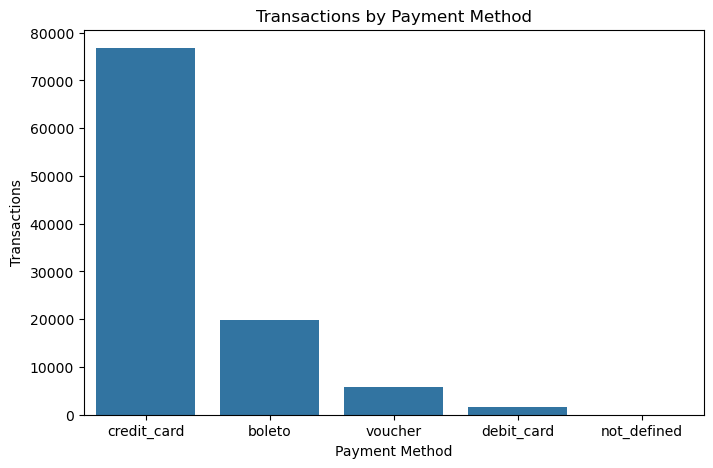

In [59]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=payment_count,
    x="payment_type",
    y="transactions"
)
plt.title("Transactions by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Transactions")
plt.show()

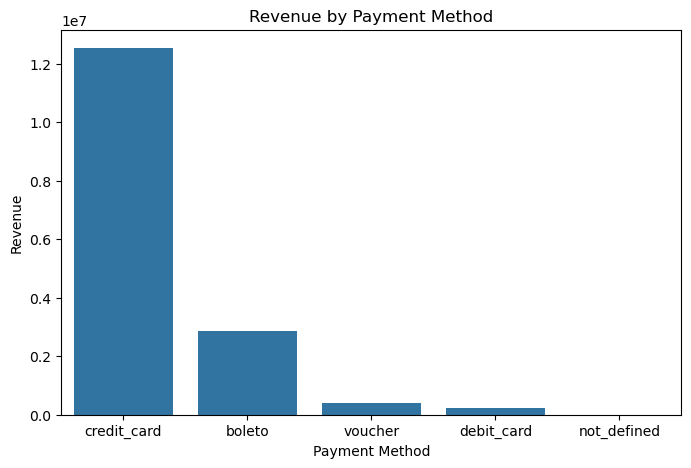

In [60]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=payment_revenue,
    x="payment_type",
    y="payment_value"
)
plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue")
plt.show()

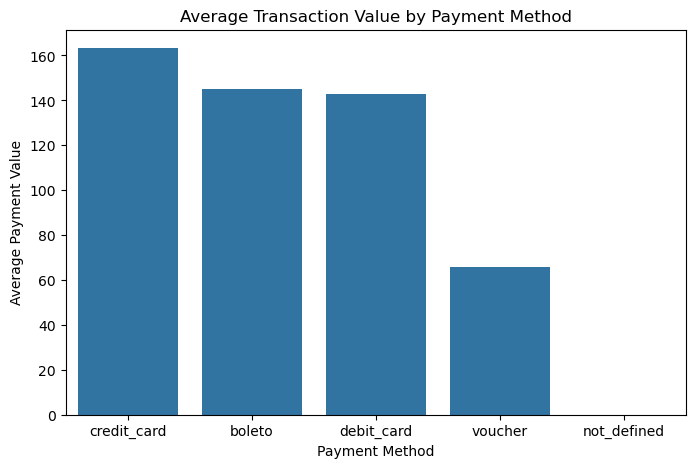

In [61]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=avg_payment,
    x="payment_type",
    y="payment_value"
)
plt.title("Average Transaction Value by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Average Payment Value")
plt.show()

In [62]:
installments = (
    payment_data.groupby(
        "payment_installments"
    )["payment_value"]
    .mean()
    .reset_index()
)
installments.head(10)

,payment_installments,payment_value
0,0,94.315000
1,1,112.420229
2,2,127.228150
3,3,142.539317
4,4,163.976840
5,5,183.465222
6,6,209.849952
7,7,187.673672
8,8,307.737427
9,9,203.440870


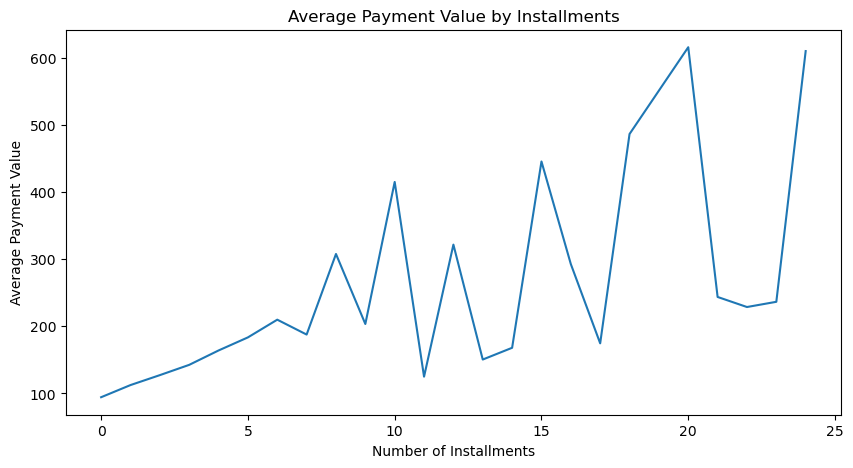

In [63]:
plt.figure(figsize=(10,5))
plt.plot(
    installments["payment_installments"],
    installments["payment_value"]
)
plt.title(
    "Average Payment Value by Installments"
)
plt.xlabel("Number of Installments")
plt.ylabel("Average Payment Value")
plt.show()

In [64]:
payment_revenue["revenue_percent"] = (
    payment_revenue["payment_value"]
    /
    payment_revenue["payment_value"].sum()
) * 100
payment_revenue

,payment_type,payment_value,revenue_percent
1,credit_card,12542084.19,78.344584
0,boleto,2869361.27,17.923569
4,voucher,379436.87,2.370166
2,debit_card,217989.79,1.361681
3,not_defined,0.00,0.000000


In [65]:
payment_revenue.to_csv(
    "payment_method_analysis.csv",
    index=False
)

## Business Insight

Credit cards account for the largest share of transactions and revenue, making them the dominant payment method.

Payment methods with higher average transaction values may indicate customer preference for premium purchases.

Installment-based payments appear to support higher-value orders, suggesting that flexible payment options can encourage larger purchases.

The company should continue optimizing the checkout experience for the most frequently used payment methods while promoting installment options for higher-priced products.

# Which sellers contribute the most value?

In [66]:
seller_data = order_items.merge(
    sellers,
    on="seller_id",
    how="left"
)
seller_data.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,27277,volta redonda,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,3471,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,37564,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,14403,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,87900,loanda,PR


In [67]:
seller_data["revenue"] = (
    seller_data["price"] +
    seller_data["freight_value"]
)

In [68]:
seller_revenue = (
    seller_data.groupby("seller_id")["revenue"]
    .sum()
    .reset_index()
    .sort_values(
        by="revenue",
        ascending=False
    )
)
seller_revenue.head(10)

,seller_id,revenue
857,4869f7a5dfa277a7dca6462dcf3b52b2,249640.70
1535,7c67e1448b00f6e969d365cea6b010ab,239536.44
1013,53243585a1d6dc2643021fd1853d8905,235856.68
881,4a3ca9315b744ce9f8e9374361493884,235539.96
3024,fa1c13f2614d7b5c4749cbc52fecda94,204084.73
2643,da8622b14eb17ae2831f4ac5b9dab84a,185192.32
1560,7e93a43ef30c4f03f38b393420bc753a,182754.05
192,1025f0e2d44d7041d6cf58b6550e0bfa,172860.69
1505,7a67c85e85bb2ce8582c35f2203ad736,162648.38
1824,955fee9216a65b617aa5c0531780ce60,160602.68


In [69]:
seller_orders = (
    seller_data.groupby("seller_id")["order_id"]
    .nunique()
    .reset_index(name="total_orders")
    .sort_values(
        by="total_orders",
        ascending=False
    )
)
seller_orders.head(10)

,seller_id,total_orders
1235,6560211a19b47992c3666cc44a7e94c0,1854
881,4a3ca9315b744ce9f8e9374361493884,1806
2481,cc419e0650a3c5ba77189a1882b7556a,1706
368,1f50f920176fa81dab994f9023523100,1404
2643,da8622b14eb17ae2831f4ac5b9dab84a,1314
1824,955fee9216a65b617aa5c0531780ce60,1287
1505,7a67c85e85bb2ce8582c35f2203ad736,1160
2836,ea8482cd71df3c1969d7b9473ff13abc,1146
857,4869f7a5dfa277a7dca6462dcf3b52b2,1132
731,3d871de0142ce09b7081e2b9d1733cb1,1080


In [70]:
seller_state_revenue = (
    seller_data.groupby(
        "seller_state"
    )["revenue"]
    .sum()
    .reset_index()
    .sort_values(
        by="revenue",
        ascending=False
    )
)
seller_state_revenue.head(10)

,seller_state,revenue
22,SP,10235883.88
15,PR,1458900.73
8,MG,1224159.80
16,RJ,937814.12
20,SC,738973.13
19,RS,435802.63
2,BA,305262.24
4,DF,116243.54
13,PE,103886.31
6,GO,78964.71


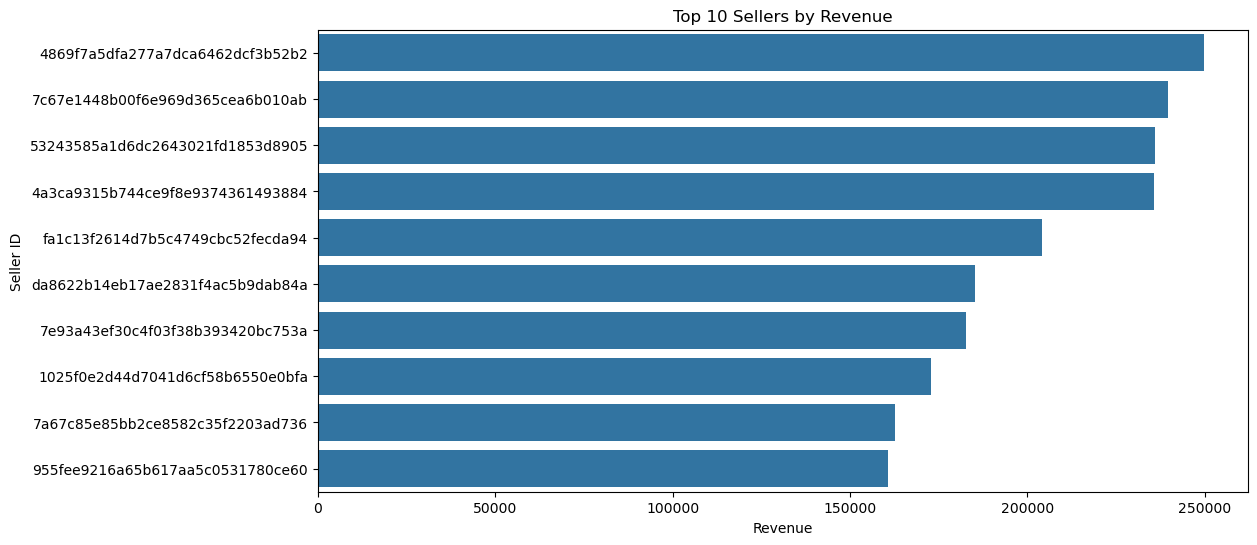

In [71]:
top_sellers = seller_revenue.head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_sellers,
    x="revenue",
    y="seller_id"
)
plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Seller ID")
plt.show()

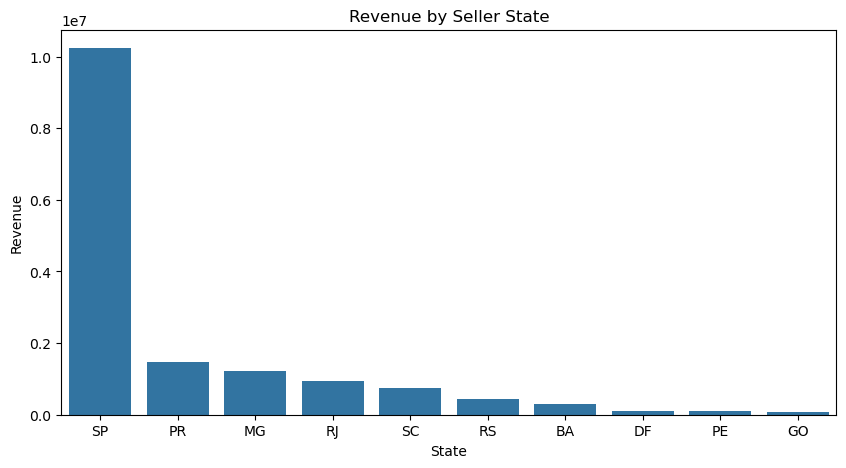

In [72]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=seller_state_revenue.head(10),
    x="seller_state",
    y="revenue"
)
plt.title("Revenue by Seller State")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.show()

In [73]:
seller_revenue["revenue_percent"] = (
    seller_revenue["revenue"]
    /
    seller_revenue["revenue"].sum()
) * 100
seller_revenue.head(10)

,seller_id,revenue,revenue_percent
857,4869f7a5dfa277a7dca6462dcf3b52b2,249640.70,1.575661
1535,7c67e1448b00f6e969d365cea6b010ab,239536.44,1.511886
1013,53243585a1d6dc2643021fd1853d8905,235856.68,1.488660
881,4a3ca9315b744ce9f8e9374361493884,235539.96,1.486661
3024,fa1c13f2614d7b5c4749cbc52fecda94,204084.73,1.288125
2643,da8622b14eb17ae2831f4ac5b9dab84a,185192.32,1.168881
1560,7e93a43ef30c4f03f38b393420bc753a,182754.05,1.153492
192,1025f0e2d44d7041d6cf58b6550e0bfa,172860.69,1.091047
1505,7a67c85e85bb2ce8582c35f2203ad736,162648.38,1.026590
1824,955fee9216a65b617aa5c0531780ce60,160602.68,1.013678


In [74]:
top_seller_id = seller_revenue.iloc[0]["seller_id"]

seller_data[
    seller_data["seller_id"] == top_seller_id
].head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,revenue
108,003d804eef0e1b856881cd18e0cc0d4c,1,41402af2a88247152583bb812ba235dd,4869f7a5dfa277a7dca6462dcf3b52b2,2017-11-27 12:15:18,277.0,35.74,14840,guariba,SP,312.74
384,00f1bb0af030935db1745ee28367ea26,1,677d8ace413e0060fa8686cde56eaf10,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-08 23:31:34,268.9,19.98,14840,guariba,SP,288.88
450,010f223ddbec749e95ef3f5414f9c4ee,1,24e8c79f39c68fbdbd57a5813ae72b94,4869f7a5dfa277a7dca6462dcf3b52b2,2018-06-13 20:31:51,79.0,18.43,14840,guariba,SP,97.43
542,013d92e415d1de7bf3b3b706f1b6d292,1,8317b177579dd27ff068b83205e2169b,4869f7a5dfa277a7dca6462dcf3b52b2,2018-02-01 14:22:15,188.0,16.07,14840,guariba,SP,204.07
625,01721e0729fcb75ab238248fdbb48eeb,1,7a10781637204d8d10485c71a6108a2e,4869f7a5dfa277a7dca6462dcf3b52b2,2018-03-23 13:49:35,219.0,24.11,14840,guariba,SP,243.11


In [75]:
seller_revenue.to_csv(
    "seller_revenue_analysis.csv",
    index=False
)

## Business Insight

A small group of sellers contributes a significant portion of total marketplace revenue.

These top-performing sellers are critical to platform success and should be supported through seller retention programs, promotional opportunities, and operational assistance.

Revenue concentration among a limited number of sellers may also represent a business risk, making it important to diversify seller performance across the marketplace.

# How do review scores vary across categories or regions?

In [76]:
review_data = reviews.merge(
    orders,
    on="order_id",
    how="left"
)
review_data.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_month,day_name
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59,41dcb106f807e993532d446263290104,delivered,2018-01-11 15:30:49,2018-01-11 15:47:59,2018-01-12 21:57:22,2018-01-17 18:42:41,2018-02-02,2018-01,Thursday
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13,8a2e7ef9053dea531e4dc76bd6d853e6,delivered,2018-02-28 12:25:19,2018-02-28 12:48:39,2018-03-02 19:08:15,2018-03-09 23:17:20,2018-03-14,2018-02,Wednesday
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24,e226dfed6544df5b7b87a48208690feb,delivered,2018-02-03 09:56:22,2018-02-03 10:33:41,2018-02-06 16:18:28,2018-02-16 17:28:48,2018-03-09,2018-02,Saturday
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,de6dff97e5f1ba84a3cd9a3bc97df5f6,delivered,2017-04-09 17:41:13,2017-04-09 17:55:19,2017-04-10 14:24:47,2017-04-20 09:08:35,2017-05-10,2017-04,Sunday
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53,5986b333ca0d44534a156a52a8e33a83,delivered,2018-02-10 10:59:03,2018-02-10 15:48:21,2018-02-15 19:36:14,2018-02-28 16:33:35,2018-03-09,2018-02,Saturday


In [77]:
review_distribution = (
    review_data["review_score"]
    .value_counts()
    .sort_index()
)
print(review_distribution)

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


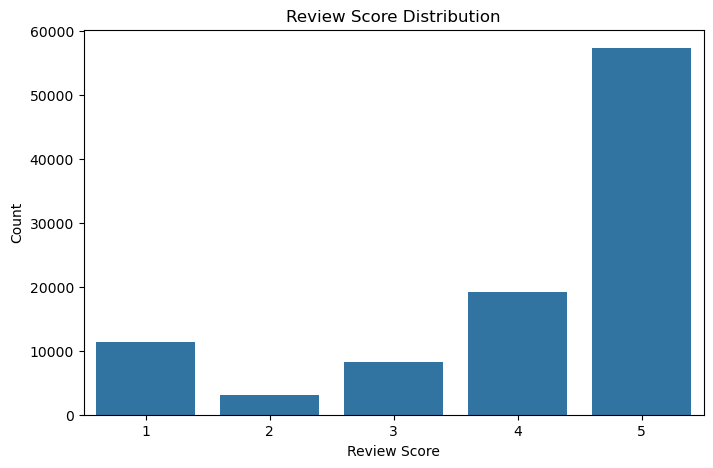

In [78]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=review_data,
    x="review_score"
)
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()

In [79]:
review_category = (
    reviews
    .merge(order_items,on="order_id")
    .merge(products,on="product_id")
)
review_category.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59,1,fd25ab760bfbba13c198fa3b4f1a0cd3,6d803cb79cc31c41c4c789a75933b3c7,2018-01-18 15:47:59,185.00,13.63,esporte_lazer,42.0,858.0,1.0,1300.0,30.0,30.0,35.0,sports_leisure
1,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59,2,fd25ab760bfbba13c198fa3b4f1a0cd3,6d803cb79cc31c41c4c789a75933b3c7,2018-01-18 15:47:59,185.00,13.63,esporte_lazer,42.0,858.0,1.0,1300.0,30.0,30.0,35.0,sports_leisure
2,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13,1,be0dbdc3d67d55727a65d4cd696ca73c,8e6d7754bc7e0f22c96d255ebda59eba,2018-03-06 12:48:39,79.79,8.30,informatica_acessorios,47.0,493.0,1.0,245.0,19.0,14.0,14.0,computers_accessories
3,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24,1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-02-08 10:31:15,149.00,45.12,informatica_acessorios,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0,computers_accessories
4,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,1,52c80cedd4e90108bf4fa6a206ef6b03,a1043bafd471dff536d0c462352beb48,2017-04-13 17:55:19,179.99,42.85,ferramentas_jardim,33.0,2188.0,2.0,7650.0,20.0,20.0,20.0,garden_tools


In [80]:
category_reviews = (
    review_category.groupby(
        "product_category_name_english"
    )["review_score"]
    .mean()
    .reset_index()
    .sort_values(
        by="review_score",
        ascending=False
    )
)
category_reviews.head(10)

,product_category_name_english,review_score
11,cds_dvds_musicals,4.642857
29,fashion_childrens_clothes,4.500000
8,books_general_interest,4.446266
22,costruction_tools_tools,4.444444
35,flowers,4.419355
9,books_imported,4.400000
10,books_technical,4.368421
37,food_drink,4.315412
53,luggage_accessories,4.315257
64,small_appliances_home_oven_and_coffee,4.302632


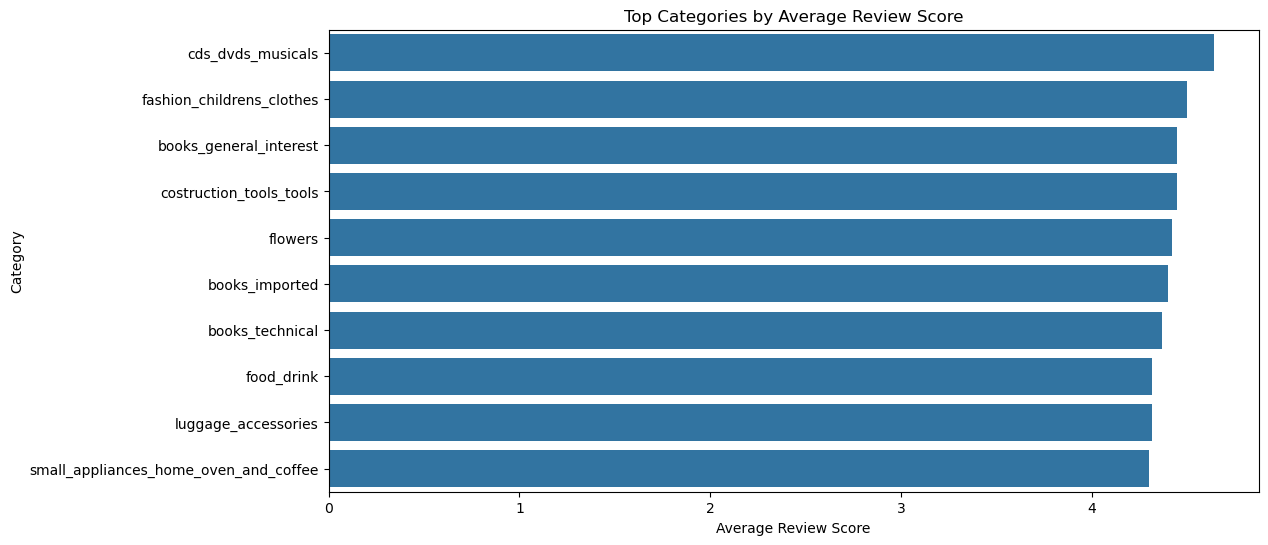

In [81]:
top_categories = category_reviews.head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_categories,
    x="review_score",
    y="product_category_name_english"
)
plt.title(
    "Top Categories by Average Review Score"
)
plt.xlabel("Average Review Score")
plt.ylabel("Category")
plt.show()

In [82]:
low_categories = (
    category_reviews.tail(10)
)
low_categories

,product_category_name_english,review_score
4,audio,3.825485
41,furniture_mattress_and_upholstery,3.815789
27,fashio_female_clothing,3.780000
58,party_supplies,3.767442
34,fixed_telephony,3.683206
30,fashion_male_clothing,3.641221
46,home_comfort_2,3.629630
57,office_furniture,3.493183
23,diapers_and_hygiene,3.256410
61,security_and_services,2.500000


In [83]:
review_region = (
    reviews
    .merge(orders,on="order_id")
    .merge(customers,on="customer_id")
)
state_reviews = (
    review_region.groupby(
        "customer_state"
    )["review_score"]
    .mean()
    .reset_index()
    .sort_values(
        by="review_score",
        ascending=False
    )
)
state_reviews.head(10)

,customer_state,review_score
3,AP,4.194030
2,AM,4.183673
17,PR,4.180032
25,SP,4.173951
10,MG,4.136172
22,RS,4.133321
11,MS,4.118785
19,RN,4.105809
12,MT,4.102990
26,TO,4.096774


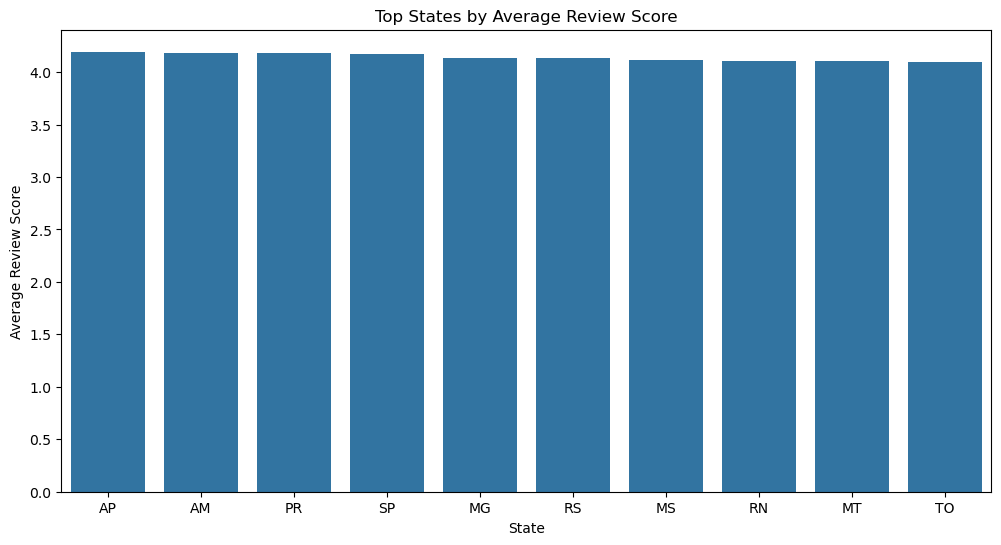

In [84]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=state_reviews.head(10),
    x="customer_state",
    y="review_score"
)
plt.title(
    "Top States by Average Review Score"
)
plt.xlabel("State")
plt.ylabel("Average Review Score")
plt.show()

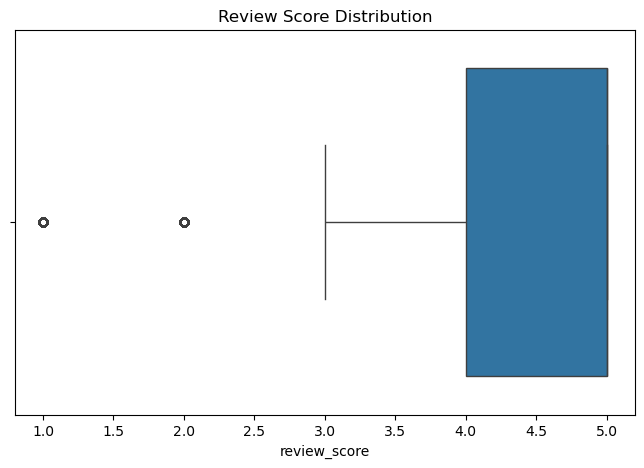

In [85]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=review_data,
    x="review_score"
)
plt.title(
    "Review Score Distribution"
)
plt.show()

In [86]:
category_reviews.to_csv(
    "category_review_analysis.csv",
    index=False
)
state_reviews.to_csv(
    "state_review_analysis.csv",
    index=False
)

## Business Insight

Most customers provide high review scores, indicating generally positive customer satisfaction across the platform.

Certain product categories consistently receive higher ratings, suggesting strong product quality and customer experience.

Categories with lower review scores should be investigated to identify potential issues related to product quality, delivery performance, or customer expectations.

Regional review analysis reveals variations in customer satisfaction, which may indicate differences in logistics performance or service quality across locations.

# What happens to sales volume across time periods?

In [87]:
time_sales = orders.merge(
    order_items,
    on="order_id",
    how="left"
)
time_sales.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_month,day_name,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,Monday,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,Tuesday,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,Wednesday,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,Saturday,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,Tuesday,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [88]:
time_sales["order_purchase_timestamp"] = pd.to_datetime(
    time_sales["order_purchase_timestamp"]
)

In [89]:
time_sales["revenue"] = (
    time_sales["price"] +
    time_sales["freight_value"]
)

In [90]:
time_sales["year"] = (
    time_sales["order_purchase_timestamp"]
    .dt.year
)
time_sales["month"] = (
    time_sales["order_purchase_timestamp"]
    .dt.month
)
time_sales["year_month"] = (
    time_sales["order_purchase_timestamp"]
    .dt.to_period("M")
)

In [91]:
monthly_revenue = (
    time_sales.groupby(
        "year_month"
    )["revenue"]
    .sum()
    .reset_index()
)
monthly_revenue.head()

,year_month,revenue
0,2016-09,354.75
1,2016-10,56808.84
2,2016-12,19.62
3,2017-01,137188.49
4,2017-02,286280.62


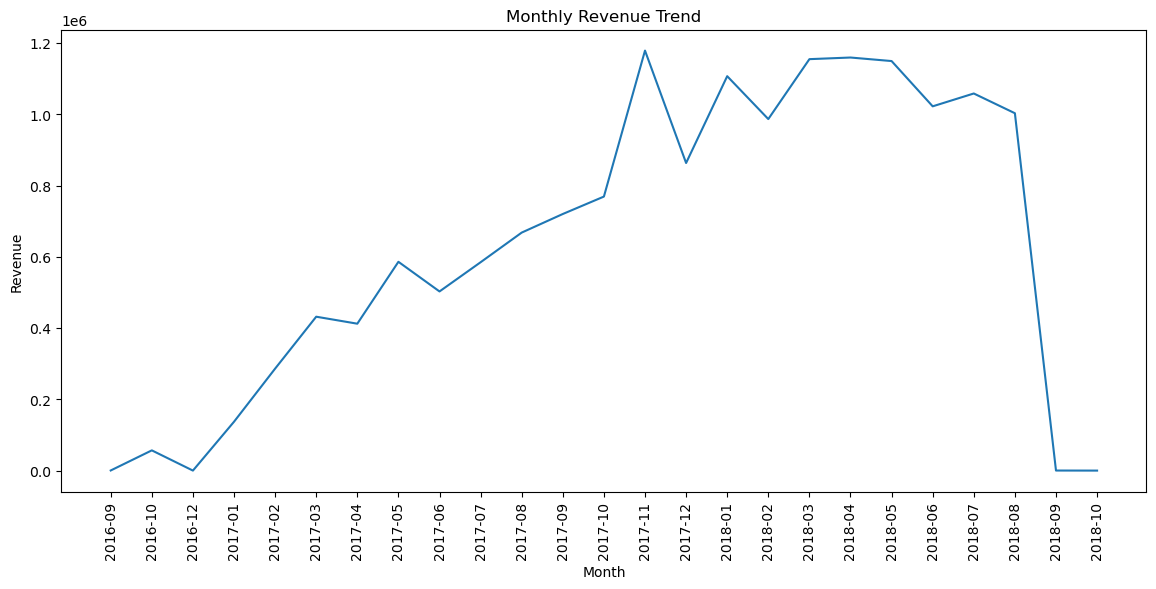

In [92]:
plt.figure(figsize=(14,6))
plt.plot(
    monthly_revenue["year_month"].astype(str),
    monthly_revenue["revenue"]
)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=90)
plt.show()

In [93]:
monthly_orders = (
    time_sales.groupby(
        "year_month"
    )["order_id"]
    .nunique()
    .reset_index(name="orders")
)
monthly_orders.head()

,year_month,orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


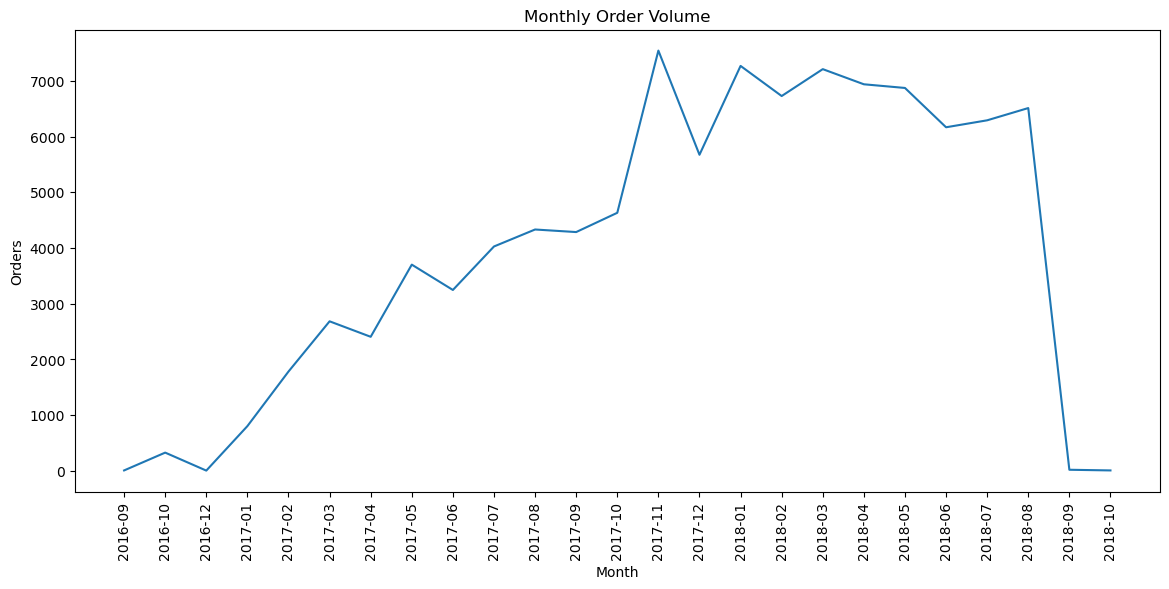

In [94]:
plt.figure(figsize=(14,6))
plt.plot(
    monthly_orders["year_month"].astype(str),
    monthly_orders["orders"]
)
plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.xticks(rotation=90)
plt.show()

In [95]:
yearly_revenue = (
    time_sales.groupby(
        "year"
    )["revenue"]
    .sum()
    .reset_index()
)
yearly_revenue

,year,revenue
0,2016,57183.21
1,2017,7142672.43
2,2018,8643697.60


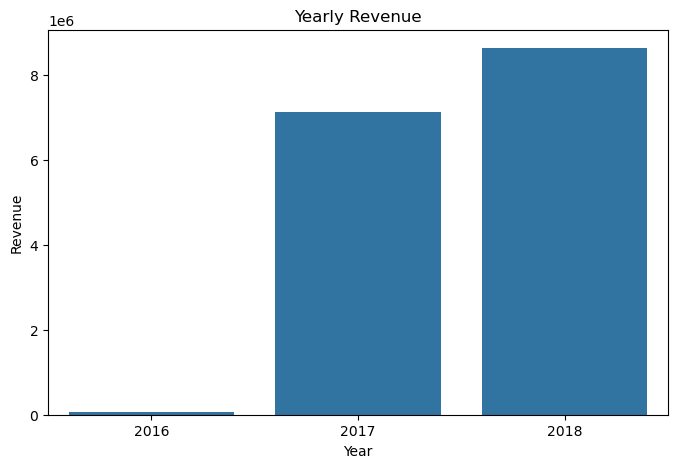

In [96]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=yearly_revenue,
    x="year",
    y="revenue"
)
plt.title("Yearly Revenue")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.show()

In [97]:
month_names = {
    1:"Jan",2:"Feb",3:"Mar",4:"Apr",
    5:"May",6:"Jun",7:"Jul",8:"Aug",
    9:"Sep",10:"Oct",11:"Nov",12:"Dec"
}
seasonality = (
    time_sales.groupby(
        "month"
    )["revenue"]
    .sum()
    .reset_index()
)
seasonality["month"] = (
    seasonality["month"]
    .map(month_names)
)
seasonality

,month,revenue
0,Jan,1244490.38
1,Feb,1273189.58
2,Mar,1587175.41
3,Apr,1572120.28
4,May,1735972.77
5,Jun,1525640.15
6,Jul,1643699.65
7,Aug,1671513.07
8,Sep,720920.12
9,Oct,826121.21


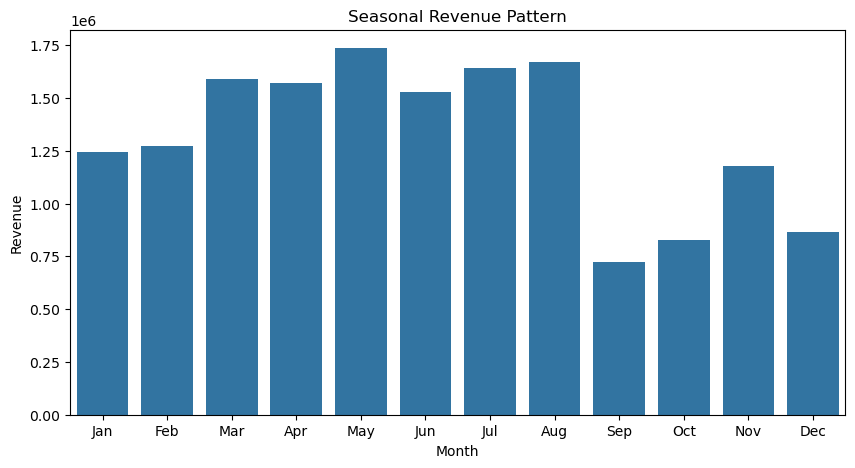

In [98]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=seasonality,
    x="month",
    y="revenue"
)
plt.title("Seasonal Revenue Pattern")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [99]:
best_month = (
    monthly_revenue.loc[
        monthly_revenue["revenue"].idxmax()
    ]
)
print(best_month)

year_month       2017-11
revenue       1179143.77
Name: 13, dtype: object


In [100]:
monthly_revenue.to_csv(
    "monthly_revenue_analysis.csv",
    index=False
)
monthly_orders.to_csv(
    "monthly_order_analysis.csv",
    index=False
)

## Business Insight

Revenue and order volume fluctuate over time, indicating seasonal purchasing patterns.

Certain months consistently generate higher sales, suggesting opportunities for targeted marketing campaigns and inventory planning.

Understanding peak and low-demand periods can help the company optimize staffing, logistics, and promotional strategies.

The monthly revenue trend provides valuable insights into business growth and customer purchasing behavior over time.

# Which customers or orders are repeated versus one-time?

In [101]:
customer_orders = (
    orders
    .merge(customers,on="customer_id")
    .groupby("customer_unique_id")["order_id"]
    .count()
    .reset_index()
)
customer_orders.columns = [
    "customer_unique_id",
    "total_orders"
]
customer_orders.head()

,customer_unique_id,total_orders
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [102]:
customer_orders["customer_type"] = np.where(
    customer_orders["total_orders"] > 1,
    "Repeat",
    "One-Time"
)
customer_orders.head()

,customer_unique_id,total_orders,customer_type
0,0000366f3b9a7992bf8c76cfdf3221e2,1,One-Time
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,One-Time
2,0000f46a3911fa3c0805444483337064,1,One-Time
3,0000f6ccb0745a6a4b88665a16c9f078,1,One-Time
4,0004aac84e0df4da2b147fca70cf8255,1,One-Time


In [103]:
customer_summary = (
    customer_orders["customer_type"]
    .value_counts()
    .reset_index()
)
customer_summary.columns = [
    "customer_type",
    "customers"
]
customer_summary

,customer_type,customers
0,One-Time,93099
1,Repeat,2997


In [104]:
customer_summary["percentage"] = (
    customer_summary["customers"]
    /
    customer_summary["customers"].sum()
) * 100
customer_summary

,customer_type,customers,percentage
0,One-Time,93099,96.881244
1,Repeat,2997,3.118756


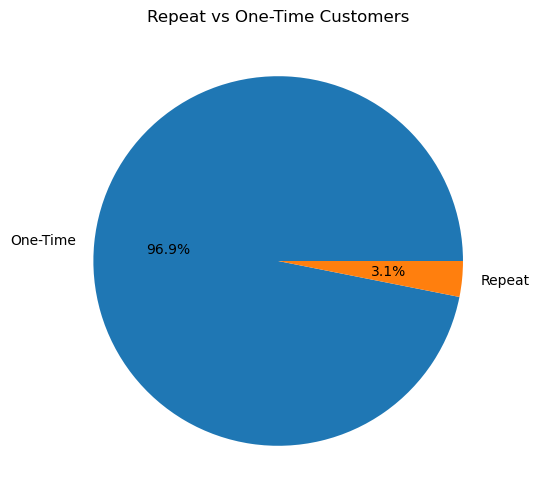

In [105]:
plt.figure(figsize=(6,6))
plt.pie(
    customer_summary["customers"],
    labels=customer_summary["customer_type"],
    autopct="%1.1f%%"
)
plt.title(
    "Repeat vs One-Time Customers"
)
plt.show()

In [106]:
customer_summary.to_csv(
    "repeat_customer_analysis.csv",
    index=False
)

Most customers appear to be one-time buyers, indicating that customer acquisition is stronger than customer retention.

Increasing repeat purchase rates through loyalty programs and personalized offers could significantly improve long-term customer value.

# What data quality issues appear in the merged dataset?

In [107]:
master_data = (
    orders
    .merge(customers,on="customer_id",how="left")
    .merge(order_items,on="order_id",how="left")
    .merge(products,on="product_id",how="left")
)
master_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_month,day_name,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,Monday,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,Tuesday,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,Wednesday,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,Saturday,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,Tuesday,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery


In [108]:
missing_report = (
    master_data.isnull()
    .sum()
    .reset_index()
)
missing_report.columns = [
    "column",
    "missing_values"
]
missing_report.sort_values(
    by="missing_values",
    ascending=False
)

,column,missing_values
6,order_delivered_customer_date,3229
28,product_category_name_english,2402
23,product_photos_qty,2378
20,product_category_name,2378
21,product_name_lenght,2378
22,product_description_lenght,2378
5,order_delivered_carrier_date,1968
26,product_height_cm,793
25,product_length_cm,793
24,product_weight_g,793


In [109]:
duplicates = master_data.duplicated().sum()
print(
    "Duplicate Rows:",
    duplicates
)

Duplicate Rows: 0


In [110]:
master_data.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date             object
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
purchase_month                        period[M]
day_name                                 object
customer_unique_id                       object
customer_zip_code_prefix                  int64
customer_city                            object
customer_state                           object
order_item_id                           float64
product_id                               object
seller_id                                object
shipping_limit_date                      object
price                                   float64
freight_value                           float64
product_category_name                   

In [111]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in date_columns:
    master_data[col] = pd.to_datetime(
        master_data[col]
    )

In [112]:
missing_percent = (
    master_data.isnull().sum()
    /
    len(master_data)
) * 100
missing_percent.sort_values(
    ascending=False
)

order_delivered_customer_date    2.846815
product_category_name_english    2.117699
product_photos_qty               2.096540
product_category_name            2.096540
product_name_lenght              2.096540
product_description_lenght       2.096540
order_delivered_carrier_date     1.735067
product_height_cm                0.699140
product_length_cm                0.699140
product_weight_g                 0.699140
product_width_cm                 0.699140
product_id                       0.683271
shipping_limit_date              0.683271
order_item_id                    0.683271
seller_id                        0.683271
price                            0.683271
freight_value                    0.683271
order_approved_at                0.141944
customer_zip_code_prefix         0.000000
customer_city                    0.000000
order_purchase_timestamp         0.000000
customer_id                      0.000000
order_id                         0.000000
customer_unique_id               0

In [113]:
missing_report.to_csv(
    "missing_value_report.csv",
    index=False
)

Several columns contain missing values, particularly in delivery and product-related information.

Date columns were converted to proper datetime format to support time-based analysis.

Data quality checks are essential because inaccurate or incomplete records can lead to misleading business conclusions.